In [11]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from cvxopt import matrix, solvers
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.svm import SVC

# Ví dụ 1

## Cách 1

In [3]:
np.random.seed(10)
means = [[2, 2], [4, 2]]
cov = [[.3, .2], [.2, .3]]
N = 100
X0 = np.random.multivariate_normal(means[0], cov, N) # class 1
X1 = np.random.multivariate_normal(means[1], cov, N) # class -1
X = np.concatenate((X0.T, X1.T), axis = 1) # all data
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis = 1) # labels

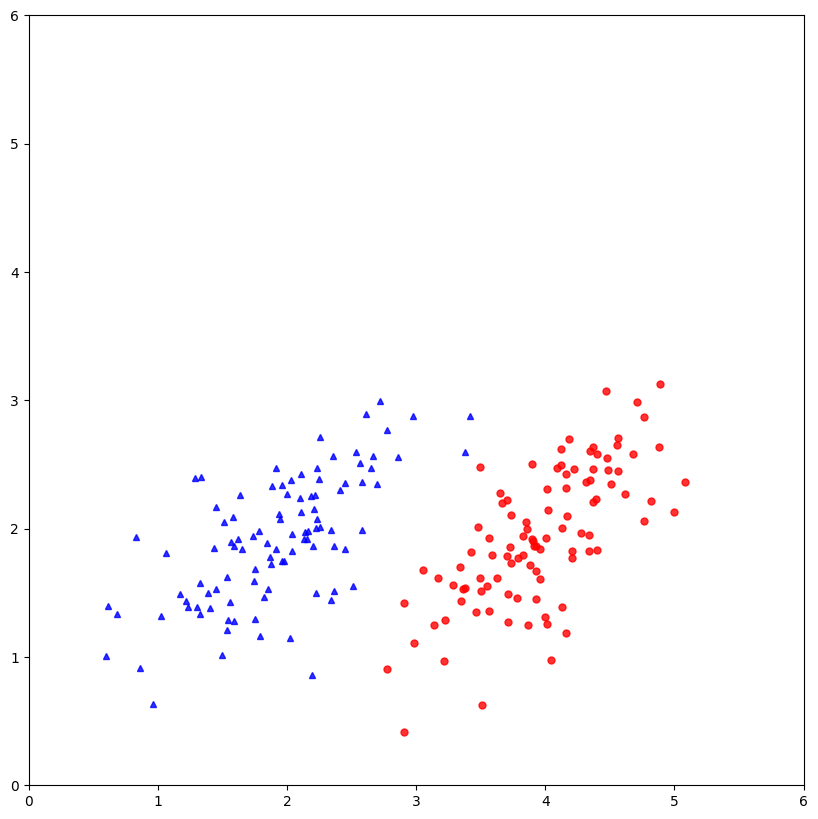

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
ani = plt.cla()
#plot points
ani = plt.plot(X0.T[0, :], X0.T[1, :], 'b^', markersize = 5, alpha = .8)
ani = plt.plot(X1.T[0, :], X1.T[1, :], 'ro', markersize = 5, alpha = .8)
ani = plt.axis([0 , 6, 0, 6])
plt.show()

In [7]:
# build P ~ K
V = np.concatenate((X0.T, -X1.T), axis = 1)
P = matrix(V.T.dot(V)) # P ~ K in slide see definition of V, K near eq (8)
q = matrix(-np.ones((2*N, 1))) # all-one vector
# build A, b, G, h
G = matrix(-np.eye(2*N)) # for all lambda_n >= 0! note that we solve -g(lambda) ->
min
h = matrix(np.zeros((2*N, 1)))
A = matrix(y) # the equality constrain is actually y^T lambda = 0
b = matrix(np.zeros((1, 1)))
solvers.options['show_progress'] = False
sol = solvers.qp(P, q, G, h, A, b)
l = np.array(sol['x']) # lambda
print('lambda = ')
print(l.T)

lambda = 
[[6.43830372e-10 4.72988123e-10 6.96301261e-10 5.79332567e-10
  5.85394979e-10 5.88997480e-10 4.89184241e-10 5.67664894e-10
  4.93959294e-10 8.11159682e-10 7.35998382e+01 5.84752419e-10
  6.33981206e-10 5.70452608e-10 5.33265242e-10 6.21992621e-10
  6.30547706e-10 6.42898737e-10 6.23309373e-10 7.19237900e-10
  6.37162151e-10 5.62750934e-10 5.43352984e-10 5.34317125e-10
  6.12473191e-10 5.54489279e-10 5.15178968e-10 6.11949009e-10
  7.11337568e-10 6.01640553e-10 6.16174828e-10 7.08582794e-10
  6.28907978e-10 9.47883550e-10 5.60470453e-10 5.73546044e-10
  5.40206464e-10 5.84839273e-10 4.52413498e-10 5.71685468e-10
  6.69868839e-10 4.47707836e-10 3.99526097e-10 5.50379371e-10
  8.79639914e-10 6.28698683e-10 6.73190935e-10 6.03403938e-10
  5.36740042e-10 1.22567795e-09 8.50987129e-10 4.93131967e-10
  6.05327442e-10 5.32588255e-10 7.14356409e-10 6.36992251e-10
  7.63436068e-10 5.89166800e-10 5.36104164e-10 9.45023473e-10
  6.67949637e-10 6.12129203e-10 6.46493582e-10 6.24525894e-1

In [ ]:
epsilon = 1e-6 # just a small number, greater than 1e-9, to filter values of lambda
S = np.where(l > epsilon)[0]
VS = V[:, S]
XS = X[:, S]
yS = y[:, S]
lS = l[S]
# calculate w and b
w_cvxopt = VS.dot(lS)
w0_cvxopt = np.mean(yS.T - w_cvxopt.T.dot(XS))
print('W = ', w_cvxopt.T)
print('W0 = ', w0_cvxopt)

W =  [[-10.10601344   6.8886009 ]]
W0 =  17.241417859321214


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


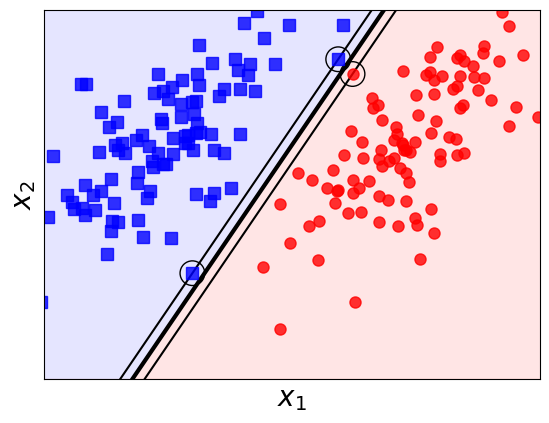

In [ ]:
with PdfPages('D:\\svm4hardmargin.pdf') as pdf:
    # draw
    # plot points
    fig, ax = plt.subplots()
    x1 = np.arange(-10, 10, 0.1)
    y1 = -w_cvxopt[0, 0]/w_cvxopt[1, 0]*x1 - w0_cvxopt/w_cvxopt[1, 0]
    y2 = -w_cvxopt[0, 0]/w_cvxopt[1, 0]*x1 - (w0_cvxopt-1)/w_cvxopt[1, 0]
    y3 = -w_cvxopt[0, 0]/w_cvxopt[1, 0]*x1 - (w0_cvxopt+1)/w_cvxopt[1, 0]
    plt.plot(x1, y1, 'k', linewidth = 3)
    plt.plot(x1, y2, 'k')
    plt.plot(x1, y3, 'k')
    y4 = 10*x1
    plt.plot(x1, y1, 'k')
    plt.fill_between(x1, y1, color='red', alpha=0.1)
    plt.fill_between(x1, y1, y4, color = 'blue', alpha = 0.1)
    plt.plot(X0[:, 0], X0[:, 1], 'bs', markersize = 8, alpha = .8)
    plt.plot(X1[:, 0], X1[:, 1], 'ro', markersize = 8, alpha = .8)
    plt.axis('equal')
    plt.ylim(0, 3)
    plt.xlim(2, 4)
    # hide tikcs
    cur_axes = plt.gca()
    cur_axes.axes.get_xaxis().set_ticks([])
    cur_axes.axes.get_yaxis().set_ticks([])
    # add circles around support vectors
    for m in S:
        circle = plt.Circle((X[0, m], X[1, m] ), 0.1, color='k', fill = False)
        ax.add_artist(circle)

    plt.xlabel('$x_1$', fontsize = 20)
    plt.ylabel('$x_2$', fontsize = 20)
    # plt.savefig('svm4.png', bbox_inches='tight', dpi = 300)
    # pdf.savefig()
    plt.show()

## Cách 2

In [ ]:
# Copy and put code for generate data here
y1 = y.reshape((2*N,))
X1 = X.T # each sample is one row
clf = SVC(kernel = 'linear', C = 1e5) # just a big number
# if C is small, method will be "SoftMagin SVM",
# if C is large enough, method is near to hard margin
clf.fit(X1, y1)
w_sklearn = clf.coef_
w0_sklearn = clf.intercept_
print('w = ', w_sklearn)
print('W0 = ', w0_sklearn)

w =  [[-10.10242378   6.88613861]]
W0 =  [17.23542499]


## So sánh bộ trọng số tối ưu của hai phương pháp

In [14]:
# So sánh bộ trọng số tối ưu của 2 cách
print("="*80)
print("SO SÁNH BỘ TRỌNG SỐ TỐI ƯU CỦA 2 CÁCH")
print("="*80)

print("\n1. CÁCH 1: Giải bài toán Dual bằng CVXOPT")
print(f"   w  = {w_cvxopt.T}")
print(f"   w0 = {w0_cvxopt:.6f}")

print("\n2. CÁCH 2: Sử dụng sklearn.svm.SVC (C=1e5)")
print(f"   w  = {w_sklearn}")
print(f"   w0 = {w0_sklearn[0]:.6f}")

print("\n3. SO SÁNH CHI TIẾT:")
print("-"*80)

# Chuyển w_sklearn về shape giống cvxopt để so sánh
w_sklearn_T = w_sklearn.T

# So sánh w
w_diff = np.abs(w_cvxopt - w_sklearn_T)
w_relative_error = np.linalg.norm(w_diff) / np.linalg.norm(w_cvxopt) * 100

print(f"\n   a) Trọng số w:")
print(f"      - Cvxopt:  w1 = {w_cvxopt[0,0]:.6f}, w2 = {w_cvxopt[1,0]:.6f}")
print(f"      - Sklearn: w1 = {w_sklearn_T[0,0]:.6f}, w2 = {w_sklearn_T[1,0]:.6f}")
print(f"      - Chênh lệch: Δw1 = {w_diff[0,0]:.6f}, Δw2 = {w_diff[1,0]:.6f}")
print(f"      - Relative Error: {w_relative_error:.4f}%")

# So sánh w0
w0_diff = np.abs(w0_cvxopt - w0_sklearn[0])
w0_relative_error = np.abs(w0_diff / w0_cvxopt) * 100

print(f"\n   b) Bias w0:")
print(f"      - Cvxopt:  w0 = {w0_cvxopt:.6f}")
print(f"      - Sklearn: w0 = {w0_sklearn[0]:.6f}")
print(f"      - Chênh lệch: Δw0 = {w0_diff:.6f}")
print(f"      - Relative Error: {w0_relative_error:.4f}%")

print("\n4. PHÂN TÍCH KẾT QUẢ:")
if w_relative_error < 0.1 and w0_relative_error < 0.1:
    print("   ✓ KẾT QUẢ TƯƠNG ĐƯƠNG NHAU (sai số < 0.1%)")
    print("   → Cả hai phương pháp đều tìm được cùng một hyperplane tối ưu!")
elif w_relative_error < 1.0 and w0_relative_error < 1.0:
    print("   ✓ KẾT QUẢ RẤT GẦN NHAU (sai số < 1%)")
    print("   → Sai số nhỏ có thể do numerical precision hoặc stopping criteria")
else:
    print("   ⚠ KẾT QUẢ CÓ CHÊNH LỆCH")
    print("   → Cần kiểm tra lại implementation hoặc tham số C")

# Tính margin
margin_cvxopt = 2.0 / np.linalg.norm(w_cvxopt)
margin_sklearn = 2.0 / np.linalg.norm(w_sklearn)

print(f"\n5. MARGIN (khoảng cách giữa 2 hyperplane song song):")
print(f"   - Cvxopt:  margin = {margin_cvxopt:.6f}")
print(f"   - Sklearn: margin = {margin_sklearn:.6f}")
print(f"   - Chênh lệch: {np.abs(margin_cvxopt - margin_sklearn):.6f}")

# Kiểm tra Support Vectors
print(f"\n6. SUPPORT VECTORS:")
print(f"   - Cvxopt:  {len(S)} support vectors (indices: {S.tolist()})")
print(f"   - Sklearn: {len(clf.support_)} support vectors (indices: {clf.support_.tolist()})")

# Kiểm tra xem có cùng support vectors không
if set(S.tolist()) == set(clf.support_.tolist()):
    print("   ✓ Cả hai phương pháp tìm được CÙNG support vectors!")
else:
    print("   ⚠ Support vectors có thể khác nhau:")
    only_cvxopt = set(S.tolist()) - set(clf.support_.tolist())
    only_sklearn = set(clf.support_.tolist()) - set(S.tolist())
    if only_cvxopt:
        print(f"      - Chỉ có trong Cvxopt: {only_cvxopt}")
    if only_sklearn:
        print(f"      - Chỉ có trong Sklearn: {only_sklearn}")

print("\n" + "="*80)
print("KẾT LUẬN:")
print("="*80)
print("✓ CVXOPT: Giải trực tiếp bài toán QP dual - chính xác về mặt toán học")
print("✓ SKLEARN: Sử dụng thuật toán tối ưu hiệu quả (SMO) - nhanh với dữ liệu lớn")
print("✓ Với Hard Margin SVM, cả hai phương pháp đều cho hyperplane tối ưu tương tự!")
print("="*80)

SO SÁNH BỘ TRỌNG SỐ TỐI ƯU CỦA 2 CÁCH

1. CÁCH 1: Giải bài toán Dual bằng CVXOPT
   w  = [[-10.10242378]
 [  6.88613861]]


TypeError: unsupported format string passed to numpy.ndarray.__format__